<a href="https://colab.research.google.com/github/nicholas-ackley/CS4485/blob/main/Alpha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Mount Google Drive
Access the OpenNeuro EEG dataset stored in Google Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Extract OpenNeuro Dataset
Unzip the dataset so the EEG files can be accessed in Colab.

In [5]:
!unzip -q /content/drive/MyDrive/openneuro_data.zip -d /content/

In [8]:
!pip install mne scipy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 34.0 MB/s eta 0:00:00


In [9]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

In [11]:
data_root = "/content/Senior Design"

##  Loading and Inspecting Sample EEG File


In [12]:
test_file = data_root + "/sub-001/eeg/sub-001_task-eyesclosed_eeg.set"
raw = mne.io.read_raw_eeglab(test_file, preload=True)
raw

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [13]:
print(raw.ch_names)
print(raw.info['sfreq'])

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
500.0


In [14]:
labels_file_path = data_root + "/participants.tsv"
labels_df = pd.read_csv(labels_file_path, sep="\t")
print(labels_df.head())
print(labels_df.columns)

  participant_id Gender  Age Group  MMSE
0        sub-001      F   57     A    16
1        sub-002      F   78     A    22
2        sub-003      M   70     A    14
3        sub-004      F   67     A    20
4        sub-005      M   70     A    22
Index(['participant_id', 'Gender', 'Age', 'Group', 'MMSE'], dtype='object')


In [15]:
Y = labels_df["Group"].iloc[:65]
print(Y.value_counts())

Group
A    36
C    29
Name: count, dtype: int64


##  Alpha Band Power Analysis


In [20]:


alpha_AD = []
alpha_HC = []

for i in range(1, 66):
    file_path = data_root + f"/sub-{i:03}/eeg/sub-{i:03}_task-eyesclosed_eeg.set"
    raw = mne.io.read_raw_eeglab(file_path, preload=True)
    fs = raw.info['sfreq']

    data = raw.get_data()
    channel_names = raw.ch_names


    if "P3" in channel_names:
        ch_idx = channel_names.index("P3")
    else:
        print(f"P3 not found for sub-{i:03}")
        continue

    signal = data[ch_idx]

    freqs, psd = welch(signal, fs=fs)

    alpha_band = (freqs >= 8) & (freqs <= 13)
    alpha_power = np.mean(psd[alpha_band])

    if Y.iloc[i-1] == "A":
        alpha_AD.append(alpha_power)
    elif Y.iloc[i-1] == "C":
        alpha_HC.append(alpha_power)

print("Average Alpha Power (AD):", np.mean(alpha_AD))
print("Average Alpha Power (HC):", np.mean(alpha_HC))

Average Alpha Power (AD): 1.9594732223168636e-11
Average Alpha Power (HC): 1.5896020153455014e-11


##  Alpha Power Comparison


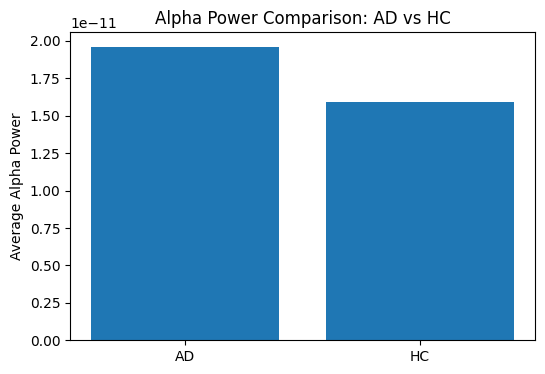

In [22]:
groups = ["AD", "HC"]
means = [np.mean(alpha_AD), np.mean(alpha_HC)]

plt.figure(figsize=(6,4))
plt.bar(groups, means)
plt.ylabel("Average Alpha Power")
plt.title("Alpha Power Comparison: AD vs HC")
plt.show()